# Clase: Mitigación de sesgos durante el preprocesamiento

Esta notebook está basada en el [tutorial de la documentación de la librería Holistic AI](https://holisticai.readthedocs.io/en/latest/gallery/tutorials/bias/mitigating_bias/binary_classification/examples/example_census_data.html)

In [ ]:
!pip install holisticai[all]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 11.2 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=f367211e6a54b1b5b05cbe727b09901b92775953788deca4eb88e24c5cb8ba7b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import pandas as pd
from holisticai.bias.metrics import classification_bias_metrics
from holisticai.datasets import load_dataset
from holisticai.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Dataset: Adult Income

La Oficina del Censo de EE. UU. ha publicado datos sobre diversos factores sociales y económicos de las personas que viven en Estados Unidos. Este conjunto de datos incluye información demográfica como edad, nivel educativo y clase laboral, así como atributos sensibles como la raza y el sexo. El objetivo de este estudio de caso es **explorar el conjunto de datos, comprender las relaciones entre las diferentes características y la variable objetivo, y evaluar la imparcialidad del conjunto de datos con respecto a los atributos protegidos.** Específicamente, investigaremos la imparcialidad en términos de raza (blanca, negra) y sexo (masculino, femenino).

**El objetivo de este estudio de caso es predecir si una persona gana más de $50,000 al año con base en las características del conjunto de datos.** Evaluaremos la imparcialidad de las predicciones del modelo utilizando las métricas de paridad demográfica e igualdad de oportunidades, y aplicaremos técnicas de mitigación de sesgos para mejorar la imparcialidad del modelo. Finalmente, comparamos el rendimiento y la imparcialidad de los modelos original y mitigado para comprender las compensaciones entre precisión y imparcialidad en este contexto.

## Análisis exploratorio de datos

[Podemos ver el detalle de los atributos en este link.](https://archive.ics.uci.edu/dataset/2/adult)

In [ ]:
dataset = load_dataset('adult', protected_attribute='sex')


dataset.data.shape

(45222, 102)

In [ ]:
ds = dataset.train_test_split(test_size=0.2)
ds

DatasetDict({
    train: <holisticai.datasets._dataset.Dataset object at 0x7cccf4a91400>,
    test: <holisticai.datasets._dataset.Dataset object at 0x7cccf56d58e0>
})

In [ ]:
dataset['X']

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25.0,226802.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,38.0,89814.0,0.0,0.0,50.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,28.0,336951.0,0.0,0.0,40.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,44.0,160323.0,7688.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,34.0,198693.0,0.0,0.0,30.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27.0,257302.0,0.0,0.0,38.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45218,40.0,154374.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45219,58.0,151910.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
45220,22.0,201490.0,0.0,0.0,20.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Evaluación de balanceo de clases



# Relación entre los atributos y la variable objetivo


<Axes: >

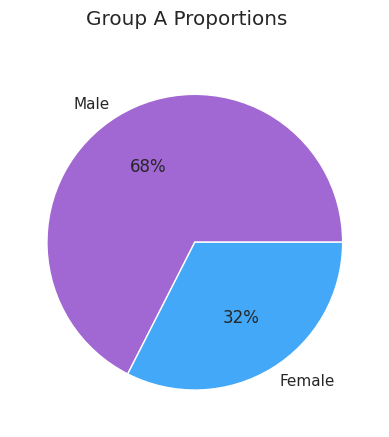

In [ ]:
from holisticai.bias.plots import group_pie_plot
group = dataset['group_a'].replace({True:'Male', False:'Female'})
group_pie_plot(group, title = 'Group A Proportions')

## Relación entre los atributos y la variable objetivo

<Axes: title={'center': 'Correlation matrix'}>

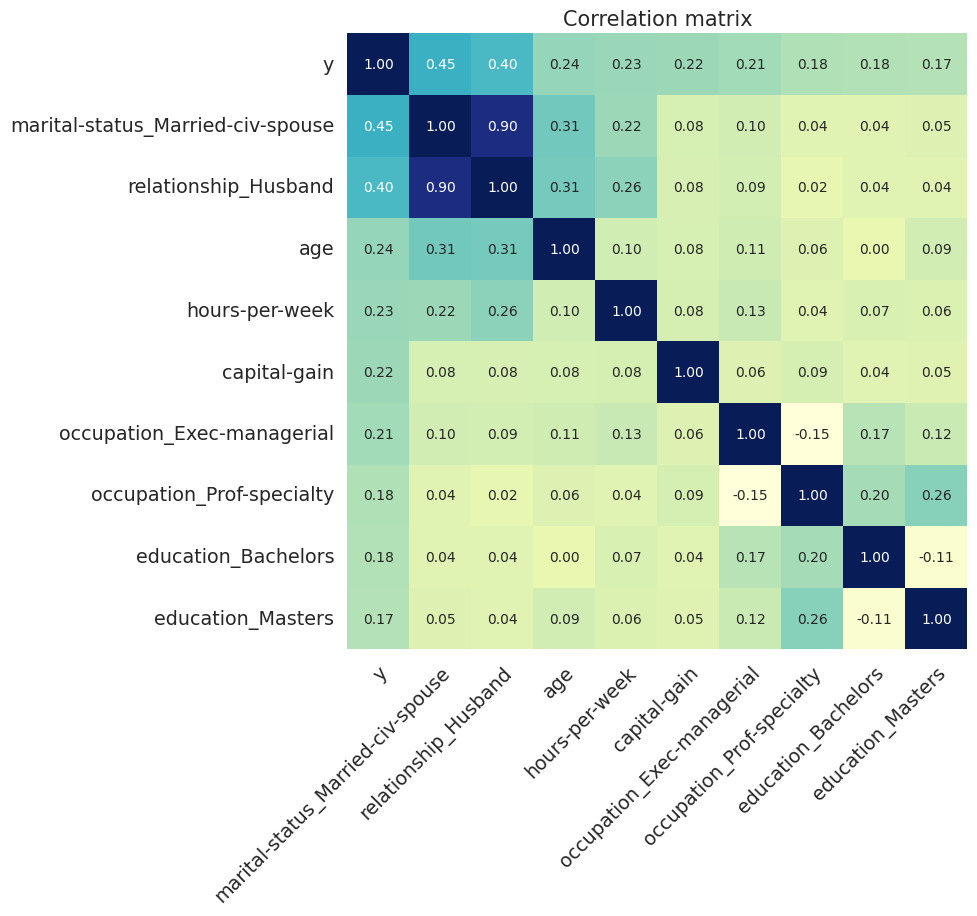

In [ ]:
from holisticai.datasets.plots import correlation_matrix_plot

correlation_matrix_plot(dataset, features = ['X'], target_feature='y',  size=(8, 8), n_features=10)

<Axes: title={'center': 'Correlation matrix'}>

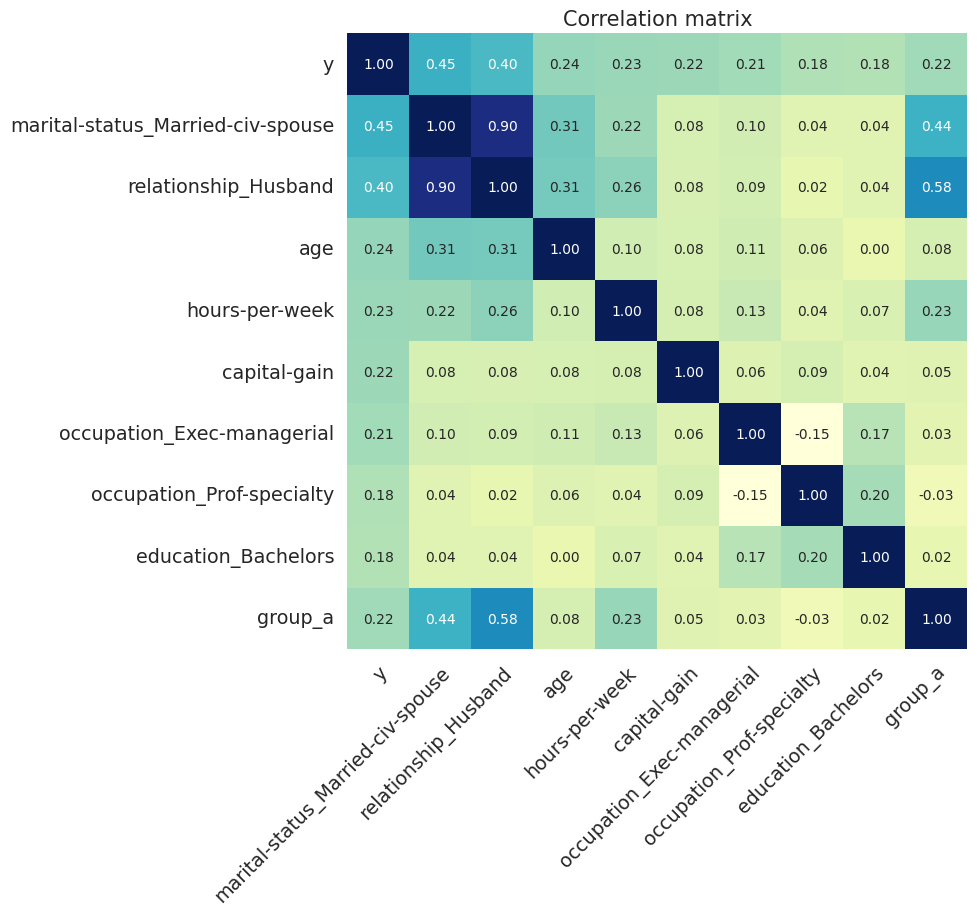

In [ ]:
from holisticai.datasets.plots import correlation_matrix_plot

correlation_matrix_plot(dataset, features = ['X'], fixed_features=['group_a'], target_feature='y',  size=(8, 8), n_features=10)

<Axes: title={'center': 'Correlation matrix'}>

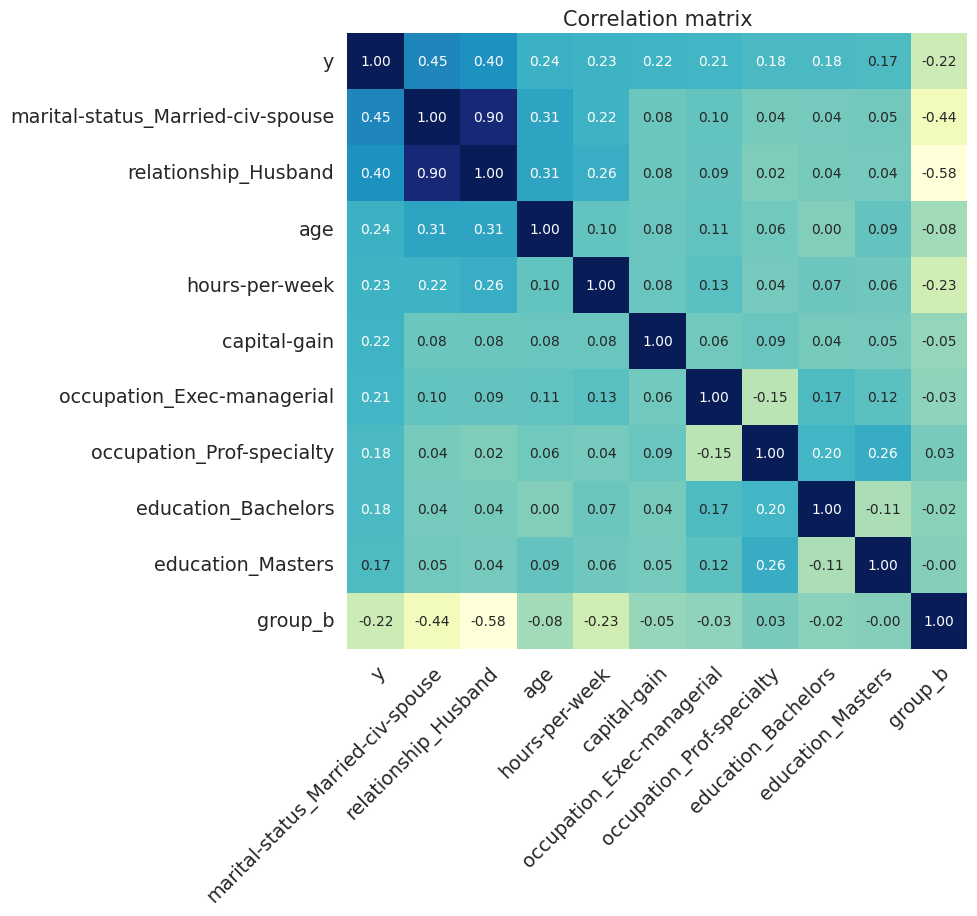

In [ ]:
from holisticai.datasets.plots import correlation_matrix_plot

correlation_matrix_plot(dataset, features = ['X'], fixed_features=['group_b'], target_feature='y',  size=(8, 8), n_features=10)

In [ ]:
from holisticai.bias.metrics import classification_bias_metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from holisticai.pipeline import Pipeline
from sklearn.metrics import accuracy_score

train_test = dataset.train_test_split(test_size=0.2, random_state=42)

# get the train and test data
train = train_test['train']
test = train_test['test']

# check the number of samples in each group
print('Train data shape:', train['X'].shape)
print('Test data shape:', test['X'].shape)

Train data shape: (36177, 97)
Test data shape: (9045, 97)


In [ ]:
# Define model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Standardize data and fit model
scaler = StandardScaler()
X_train = scaler.fit_transform(train['X'])
model.fit(X_train, train['y'])

# Predict on test data
X_test = scaler.transform(test['X'])
y_pred = model.predict(X_test)

# Evaluate bias metrics
baseline = classification_bias_metrics(test['group_a'], test['group_b'], y_pred, test['y'], metric_type='both')

# Compute accuracy
baseline_accuracy = accuracy_score(test['y'], y_pred)

In [ ]:
baseline

,Value,Reference
Metric,,
Statistical Parity,0.173873,0
Disparate Impact,2.954733,1
Four Fifths Rule,0.338440,1
Cohen D,0.438358,0
2SD Rule,19.100792,0
Equality of Opportunity Difference,0.072457,0
False Positive Rate Difference,0.072322,0
Average Odds Difference,0.072390,0
Accuracy Difference,-0.107176,0


In [ ]:
baseline_accuracy

0.8518518518518519

## Medición del sesgo en las predicciones (sin mitigación)
En este paso, entrenaremos modelos de aprendizaje automático para predecir si una persona gana más de $50,000 al año según los atributos del conjunto de datos. Para esta tarea, utilizamos un modelo clasificador Random Forest. Las métricas de sesgo utilizadas se basan tanto en la igualdad de oportunidades como en la igualdad de resultados.

La columna "Referencia" muestra los valores que cada métrica considera justos. Por ejemplo, un Impacto Dispar de 1 indica que los resultados son justos.

## Mitigación de Sesgos
### Preprocesamiento

**1. Reweighting**


In [ ]:
from holisticai.bias.mitigation import Reweighing
mitigator = Reweighing()

model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define pipeline
pipeline = Pipeline(steps=[('scalar', StandardScaler()), ("bm_preprocessing", mitigator), ("estimator", model),])
pipeline.fit(train['X'], train['y'], bm__group_a=train['group_a'], bm__group_b=train['group_b'])

# Make predictions
y_pred_pipeline = pipeline.predict(test['X'], bm__group_a=test['group_a'], bm__group_b=test['group_b'])

# Evaluate bias metrics for pipeline model
metrics_preprocessing_reweighing = classification_bias_metrics(test['group_a'], test['group_b'], y_pred_pipeline, test['y'], metric_type='both')

# Compute accuracy for preprocessing model
accuracy_preprocessing_reweighing = accuracy_score(test['y'], y_pred_pipeline)

In [ ]:
metrics_preprocessing_reweighing

,Value,Reference
Metric,,
Statistical Parity,0.177722,0
Disparate Impact,3.045207,1
Four Fifths Rule,0.328385,1
Cohen D,0.448023,0
2SD Rule,19.504410,0
Equality of Opportunity Difference,0.093067,0
False Positive Rate Difference,0.076573,0
Average Odds Difference,0.084820,0
Accuracy Difference,-0.108788,0


In [ ]:
train_data_transformed = mitigator.fit_transform(train['X'], train['group_a'], train['group_b'])
train_data_transformed

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,29.0,263786.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,39.0,99270.0,0.0,0.0,50.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,41.0,237452.0,0.0,0.0,15.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,21.0,109199.0,0.0,0.0,15.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,58.0,206532.0,0.0,0.0,50.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36172,39.0,497525.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
36173,36.0,114719.0,0.0,0.0,50.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
36174,53.0,38795.0,0.0,0.0,40.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
36175,57.0,186361.0,0.0,0.0,40.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
mitigator.sample_weight

array([1.0005654, 1.0005733, 1.0005733, ..., 1.       , 1.       ,
       1.       ], dtype=float32)

In [ ]:
accuracy_preprocessing_reweighing


**2. Correlation Remover**

Para el preprocesamiento, utilizaremos el algoritmo Correlation Remover para eliminar las correlaciones entre el atributo sensible y las atributos. CorrelationRemover aplica una transformación lineal a las columnas de atributos no sensibles para eliminar su correlación con las columnas de atributos sensibles, conservando al mismo tiempo la mayor cantidad de información posible (medida mediante el error de mínimos cuadrados).

In [ ]:
# Define preprocessing model
from holisticai.bias.mitigation import CorrelationRemover
mitigator = CorrelationRemover()
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define pipeline
pipeline = Pipeline(steps=[('scalar', StandardScaler()), ("bm_preprocessing", mitigator), ("estimator", model),])
pipeline.fit(train['X'], train['y'], bm__group_a=train['group_a'], bm__group_b=train['group_b'])

# Make predictions
y_pred_pipeline = pipeline.predict(test['X'], bm__group_a=test['group_a'], bm__group_b=test['group_b'])

# Evaluate bias metrics for pipeline model
metrics_preprocessing_correlationRemover = classification_bias_metrics(test['group_a'], test['group_b'], y_pred_pipeline, test['y'], metric_type='both')

# Compute accuracy for preprocessing model
accuracy_preprocessing_correlationRemover = accuracy_score(test['y'], y_pred_pipeline)

In [ ]:
metrics_preprocessing_correlationRemover

,Value,Reference
Metric,,
Statistical Parity,0.187055,0
Disparate Impact,3.259344,1
Four Fifths Rule,0.306810,1
Cohen D,0.470734,0
2SD Rule,20.448471,0
Equality of Opportunity Difference,0.103104,0
False Positive Rate Difference,0.082449,0
Average Odds Difference,0.092777,0
Accuracy Difference,-0.109688,0


In [ ]:
accuracy_preprocessing_correlationRemover

0.8515201768933113

**3. Disparate Impact**

In [ ]:
# Define preprocessing model
from holisticai.bias.mitigation import DisparateImpactRemover
mitigator = DisparateImpactRemover()
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define pipeline
pipeline = Pipeline(steps=[('scalar', StandardScaler()), ("bm_preprocessing", mitigator), ("estimator", model),])
pipeline.fit(train['X'], train['y'], bm__group_a=train['group_a'], bm__group_b=train['group_b'])

# Make predictions
y_pred_pipeline = pipeline.predict(test['X'], bm__group_a=test['group_a'], bm__group_b=test['group_b'])

# Evaluate bias metrics for pipeline model
metrics_preprocessing_disparateImpact = classification_bias_metrics(test['group_a'], test['group_b'], y_pred_pipeline, test['y'], metric_type='both')

# Compute accuracy for preprocessing model
accuracy_preprocessing_disparateImpact = accuracy_score(test['y'], y_pred_pipeline)

In [ ]:
metrics_preprocessing_disparateImpact

,Value,Reference
Metric,,
Statistical Parity,0.154118,0
Disparate Impact,3.075976,1
Four Fifths Rule,0.325100,1
Cohen D,0.409738,0
2SD Rule,17.899377,0
Equality of Opportunity Difference,0.103148,0
False Positive Rate Difference,0.049169,0
Average Odds Difference,0.076158,0
Accuracy Difference,-0.097431,0


In [ ]:
accuracy_preprocessing_disparateImpact

0.8560530679933664

## Comparación de métricas de fairness y accuracy

In [ ]:
keys = ['Baseline', 'Preprocessing Mitigator Reweighing', 'Preprocessing Mitigator Correlation Remover', 'Preprocessing Mitigator Disparate Impact Remover', 'Reference']
comparison = pd.concat([baseline['Value'], metrics_preprocessing_reweighing['Value'],metrics_preprocessing_correlationRemover['Value'],metrics_preprocessing_disparateImpact], axis=1)
comparison.columns = keys

def highlight_closest(s):
    reference = s['Reference']
    differences = s.drop('Reference').apply(lambda x: abs(x - reference))
    closest = differences.idxmin()
    return ['background-color: mediumseagreen' if x == s[closest] else '' for x in s]

comparison_highlighted = comparison.style.apply(highlight_closest, axis=1)
comparison_highlighted


,Baseline,Preprocessing Mitigator Reweighing,Preprocessing Mitigator Correlation Remover,Preprocessing Mitigator Disparate Impact Remover,Reference
Metric,,,,,
Statistical Parity,0.173873,0.177722,0.187055,0.154118,0
Disparate Impact,2.954733,3.045207,3.259344,3.075976,1
Four Fifths Rule,0.338440,0.328385,0.306810,0.325100,1
Cohen D,0.438358,0.448023,0.470734,0.409738,0
2SD Rule,19.100792,19.504410,20.448471,17.899377,0
Equality of Opportunity Difference,0.072457,0.093067,0.103104,0.103148,0
False Positive Rate Difference,0.072322,0.076573,0.082449,0.049169,0
Average Odds Difference,0.072390,0.084820,0.092777,0.076158,0
Accuracy Difference,-0.107176,-0.108788,-0.109688,-0.097431,0


In [ ]:
# Tarea: explorar el siguiente mitigador
# Define postprocessing model
from holisticai.bias.mitigation import LearningFairRepresentation

mitigator = LearningFairRepresentation(k=10, Ax=0.2, Ay=2.0, Az=4.0, verbose=1, maxiter=100, seed=100)
mitigator